In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# EN_comparsion

In [3]:
results_en=pd.read_csv('en_correlation_comparison_results.csv')

print(results_en)

        Dimension  base_Spearman  en_ft_Spearman  nl_ft_Spearman  \
0        auditory       0.351128        0.874811        0.839475   
1       gustatory       0.363268        0.562167        0.420680   
2          haptic       0.317005        0.832618        0.773478   
3   interoceptive       0.505174        0.843667        0.735882   
4       olfactory       0.485186        0.656373        0.539485   
5          visual      -0.076008        0.827285        0.787190   
6            foot       0.335782        0.799723        0.510610   
7            hand       0.142638        0.840850        0.678956   
8            head       0.328433        0.686874        0.387622   
9           mouth       0.447412        0.830847        0.703467   
10          torso       0.326744        0.765633        0.522931   

    QA_ft_Spearman  Z_base_vs_en  p_base_vs_en  Z_base_vs_nl  p_base_vs_nl  \
0         0.231852    -30.961728             0    -27.882319  0.000000e+00   
1         0.414297     -9.0

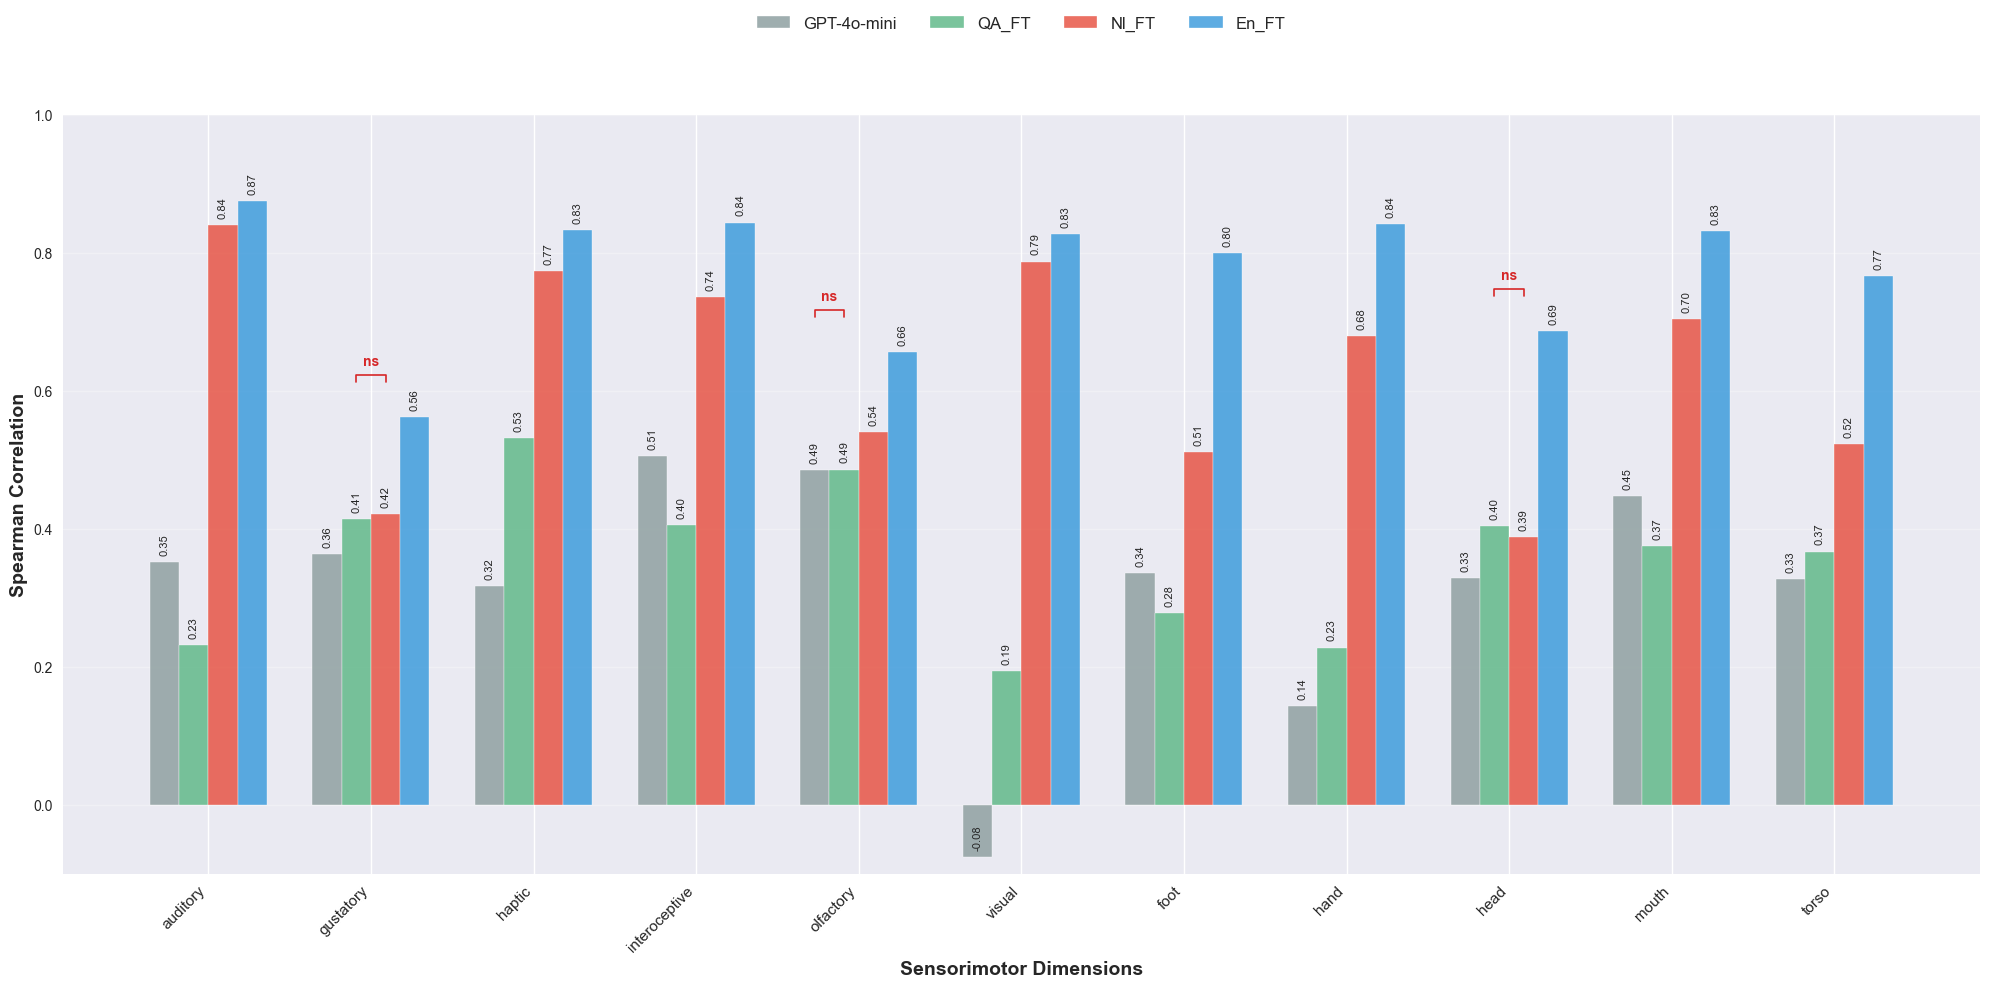

In [4]:
# Set font and style
plt.rcParams['font.sans-serif'] = ['Arial', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8')

# Data preparation
categories_spearman = results_en['Dimension']

# Data (Bars)
base_spearman = results_en['base_Spearman'].tolist()
en_ft_spearman = results_en['en_ft_Spearman'].tolist()
nl_ft_spearman = results_en['nl_ft_Spearman'].tolist()
qa_ft_spearman = results_en['QA_ft_Spearman'].tolist()

# Significance data (P-values)
p_base_vs_en = results_en['p_base_vs_en'].tolist()
p_base_vs_nl = results_en['p_base_vs_nl'].tolist()
p_en_vs_nl = results_en['p_en_vs_nl'].tolist()
p_base_vs_qa = results_en['p_base_vs_QA'].tolist()
p_en_vs_qa = results_en['p_en_vs_qa'].tolist()
p_nl_vs_qa = results_en['p_nl_vs_qa'].tolist()


# Set chart size
fig, ax = plt.subplots(figsize=(20, 10))

# Set bar width (Narrower to fit 4 bars)
bar_width = 0.18

# Set X-axis position
index = np.arange(len(categories_spearman))

# Plot bars with NEW ORDER: Base, QA, Nl, En
# Centered around 'index': -1.5w, -0.5w, +0.5w, +1.5w

# 1. Base (Position 1: Left)
rects1 = ax.bar(index - 1.5 * bar_width, base_spearman, bar_width, label='GPT-4o-mini', color='#95a5a6', alpha=0.9, edgecolor='white')

# 2. QA_FT (Position 2: Mid-Left) - Moved from pos 4
rects2 = ax.bar(index - 0.5 * bar_width, qa_ft_spearman, bar_width, label='QA_FT', color="#59b683", alpha=0.8, edgecolor='white')

# 3. Nl_FT (Position 3: Mid-Right) - Stays at pos 3
rects3 = ax.bar(index + 0.5 * bar_width, nl_ft_spearman, bar_width, label='Nl_FT', color='#e74c3c', alpha=0.8, edgecolor='white')

# 4. En_FT (Position 4: Right) - Moved from pos 2
rects4 = ax.bar(index + 1.5 * bar_width, en_ft_spearman, bar_width, label='En_FT', color='#3498db', alpha=0.8, edgecolor='white')

# Add labels and title
ax.set_xlabel('Sensorimotor Dimensions', fontsize=14, fontweight='bold')
ax.set_ylabel('Spearman Correlation', fontsize=14, fontweight='bold')
ax.set_title('', fontsize=16, fontweight='bold', pad=30)
ax.set_xticks(index)
ax.set_xticklabels(categories_spearman, rotation=45, ha='right', fontsize=11)

# Legend placed at the top (Order in legend will match plot order)
ax.legend(loc='center', bbox_to_anchor=(0.5, 1.12), ncol=4, fontsize=12, frameon=False)

# Add grid lines
ax.grid(True, axis='y', alpha=0.3)
ax.set_axisbelow(True)
# Increase Y-limit to accommodate significance markers
ax.set_ylim(-0.1, 1)

# Function to add value labels
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2., height + 0.01,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=8, rotation=90)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
autolabel(rects4)

# ===== Draw Significance Markers (Updated for New Order) =====

SIGNIFICANCE_COLOR = '#505050'
LINE_WIDTH = 1.0
VERTICAL_SPACING = 0.065
MARKER_OFFSET = 0.06

for i in range(len(index)):
    # 1. Get heights for the current dimension (New Order)
    h_base = base_spearman[i]
    h_qa = qa_ft_spearman[i]
    h_nl = nl_ft_spearman[i]
    h_en = en_ft_spearman[i]
    
    # 2. Define X positions corresponding to the new bar order
    x1 = index[i] - 1.5 * bar_width  # Base
    x2 = index[i] - 0.5 * bar_width  # QA
    x3 = index[i] + 0.5 * bar_width  # Nl
    x4 = index[i] + 1.5 * bar_width  # En

    # Initialize current stacking height
    current_y = max(h_base, h_qa, h_nl, h_en) + MARKER_OFFSET
    
    # 3. Define pairings using correct P-value variables mapped to new positions
    # Ordered by span width (narrowest first) for neat stacking
    comparisons = [
        # --- Width 1 (Adjacent bars) ---
        (p_base_vs_qa[i], x1, x2), # Base vs QA
        (p_nl_vs_qa[i],   x2, x3), # QA vs Nl (Note: p_nl_vs_qa order doesn't matter for p-value)
        (p_en_vs_nl[i],   x3, x4), # Nl vs En
        
        # --- Width 2 (Gap of 1 bar) ---
        (p_base_vs_nl[i], x1, x3), # Base vs Nl
        (p_en_vs_qa[i],   x2, x4), # QA vs En
        
        # --- Width 3 (Gap of 2 bars) ---
        (p_base_vs_en[i], x1, x4), # Base vs En
    ]
    
    # Red color for Non-Significant
    NS_COLOR = '#d62728' 
    
    for p_val, sx, ex in comparisons:
        # Only mark if Non-Significant (p >= 0.05)
        if not pd.isna(p_val) and p_val >= 0.05:
            # Draw red bracket
            ax.plot([sx, sx, ex, ex], 
                    [current_y-0.01, current_y, current_y, current_y-0.01], 
                    color=NS_COLOR, linewidth=1.2)
            # Add 'ns' label
            ax.text((sx+ex)/2, current_y + 0.01, "ns", 
                    ha='center', va='bottom', color=NS_COLOR, fontsize=10, fontweight='bold')
            # Increase height for the next bracket
            current_y += VERTICAL_SPACING

plt.tight_layout()
plt.show()

找到 11 个维度的人类评分数据。


/var/folders/tb/rtz1nxvn4k5_jn2c158qm_wm0000gn/T/ipykernel_32107/2813481612.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


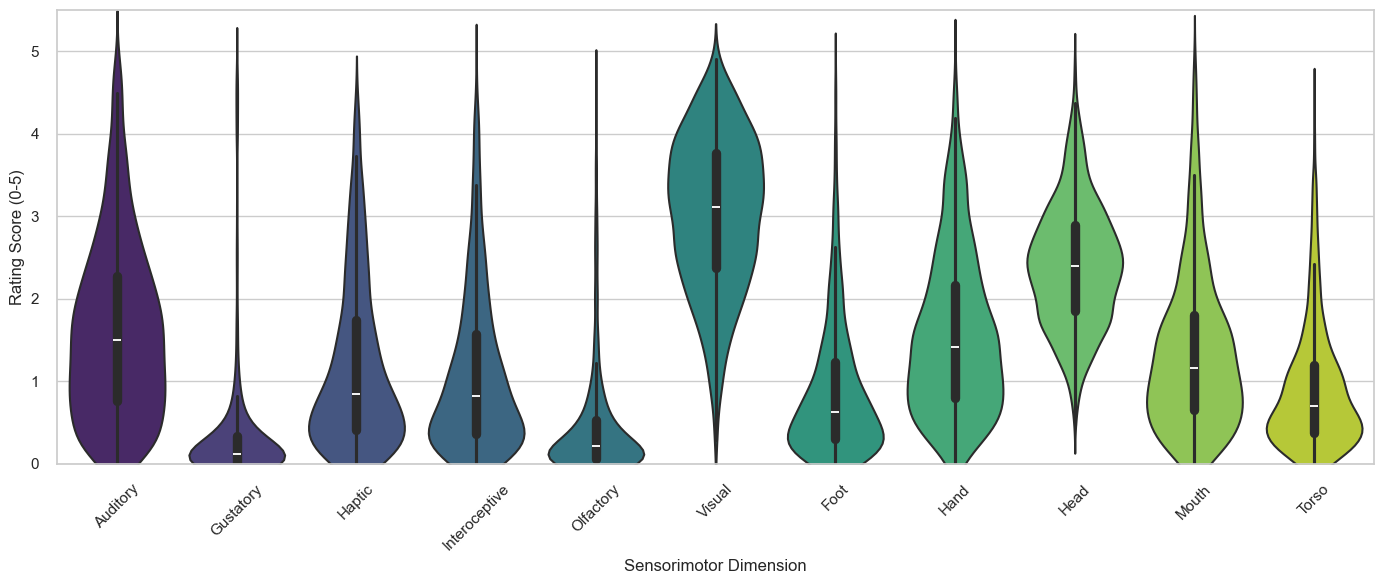

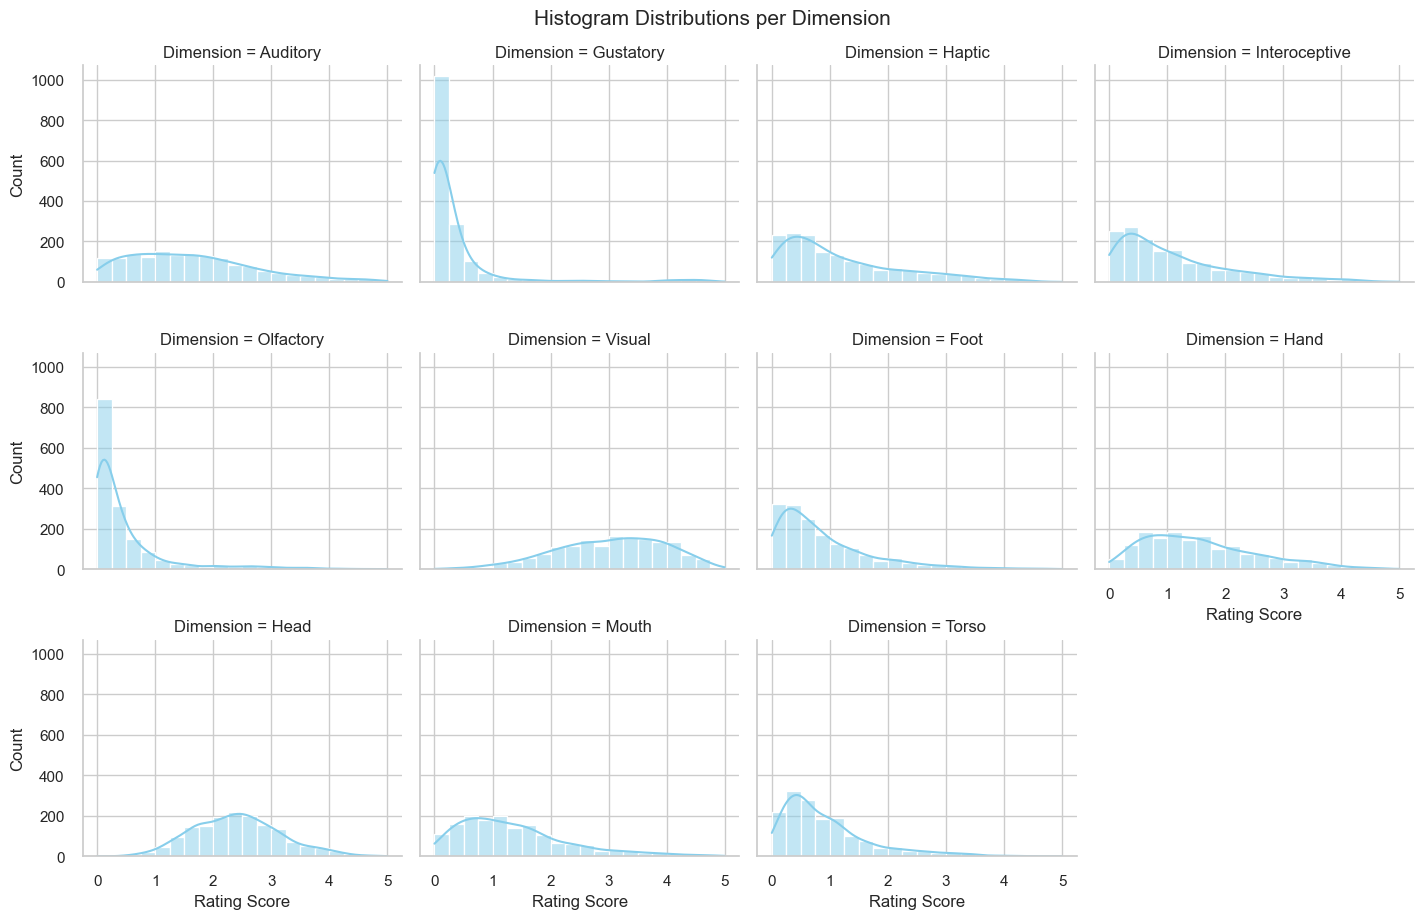

In [6]:
file_path = 'En_all_models_results.xlsx' 
df = pd.read_excel(file_path)
df.columns = df.columns.str.lower()
    
# Filter columns ending with '.mean' (human rating columns)
human_cols = [col for col in df.columns if col.endswith('.mean')]
    
if not human_cols:
    print("Error: Columns ending with '.mean' not found. Please check Excel column name format.")
else:
    print(f"Found {len(human_cols)} dimensions of human rating data.")
        
       
    df_human = df[human_cols].copy()
        
        
    df_human.columns = [c.replace('.mean', '').title() for c in df_human.columns]
        
    df_long = df_human.melt(var_name='Dimension', value_name='Rating')
        
    # Drop missing values (some words might not have ratings)
    df_long.dropna(subset=['Rating'], inplace=True)

    # ==========================================
    # 2. Plan A: Violin Plot - Recommended
    # Pros: Aesthetically pleasing, shows probability density and quartiles simultaneously
    # ==========================================
    plt.figure(figsize=(14, 6))
    sns.set_theme(style="whitegrid")
    
    sns.violinplot(
        data=df_long, 
        x='Dimension', 
        y='Rating', 
        palette="viridis",
        inner="box",   # Show inner box plot
        linewidth=1.5
    )
    
    #plt.title('Distribution of Human Ratings across Dimensions (Violin Plot)', fontsize=15, pad=20)
    plt.ylabel('Rating Score (0-5)', fontsize=12)
    plt.xlabel('Sensorimotor Dimension', fontsize=12)
    plt.xticks(rotation=45)
    plt.ylim(0, 5.5) # Assuming rating is 0-5 scale
    plt.tight_layout()
    plt.show()

    # ==========================================
    # 3. Plan B: Faceted Histogram
    # Pros: Clearly shows the shape of rating count distribution
    # ==========================================
    g = sns.displot(
        data=df_long, 
        x='Rating', 
        col='Dimension', 
        col_wrap=4,       # 4 plots per row
        kind='hist', 
        kde=True,         # Show smooth curve
        height=3, 
        aspect=1.2,
        bins=20,          # Number of histogram bins
        color='skyblue',
        edgecolor='white'
    )
    
    g.fig.suptitle('Histogram Distributions per Dimension', y=1.02, fontsize=15)
    g.set_axis_labels("Rating Score", "Count")
    plt.show()

# Nl_comparsion

In [8]:
results_nl=pd.read_csv('nl_correlation_comparison_results.csv')

print(results_nl)

   Dimension  base_Spearman  en_ft_Spearman  nl_ft_Spearman  Z_base_vs_en  \
0      Horen       0.257794        0.792791        0.813742    -24.520272   
1    Proeven       0.307197        0.550071        0.503604    -10.338728   
2     Voelen      -0.128394        0.797878        0.819121    -31.250044   
3  Sensaties       0.495872        0.728227        0.759820    -13.565614   
4     Ruiken       0.369831        0.601162        0.561963    -10.923438   
5       Zien      -0.076090        0.767698        0.835601    -29.585780   

   p_base_vs_en  Z_base_vs_nl  p_base_vs_nl  Z_en_vs_nl  p_en_vs_nl  
0             0    -26.943628  0.000000e+00   -3.185385    0.001446  
1             0     -7.795016  6.439294e-15    2.714059    0.006646  
2             0    -32.912298  0.000000e+00   -3.054540    0.002254  
3             0    -15.616962  0.000000e+00   -3.220390    0.001280  
4             0     -8.513692  0.000000e+00    2.548586    0.010816  
5             0    -33.381947  0.000000e

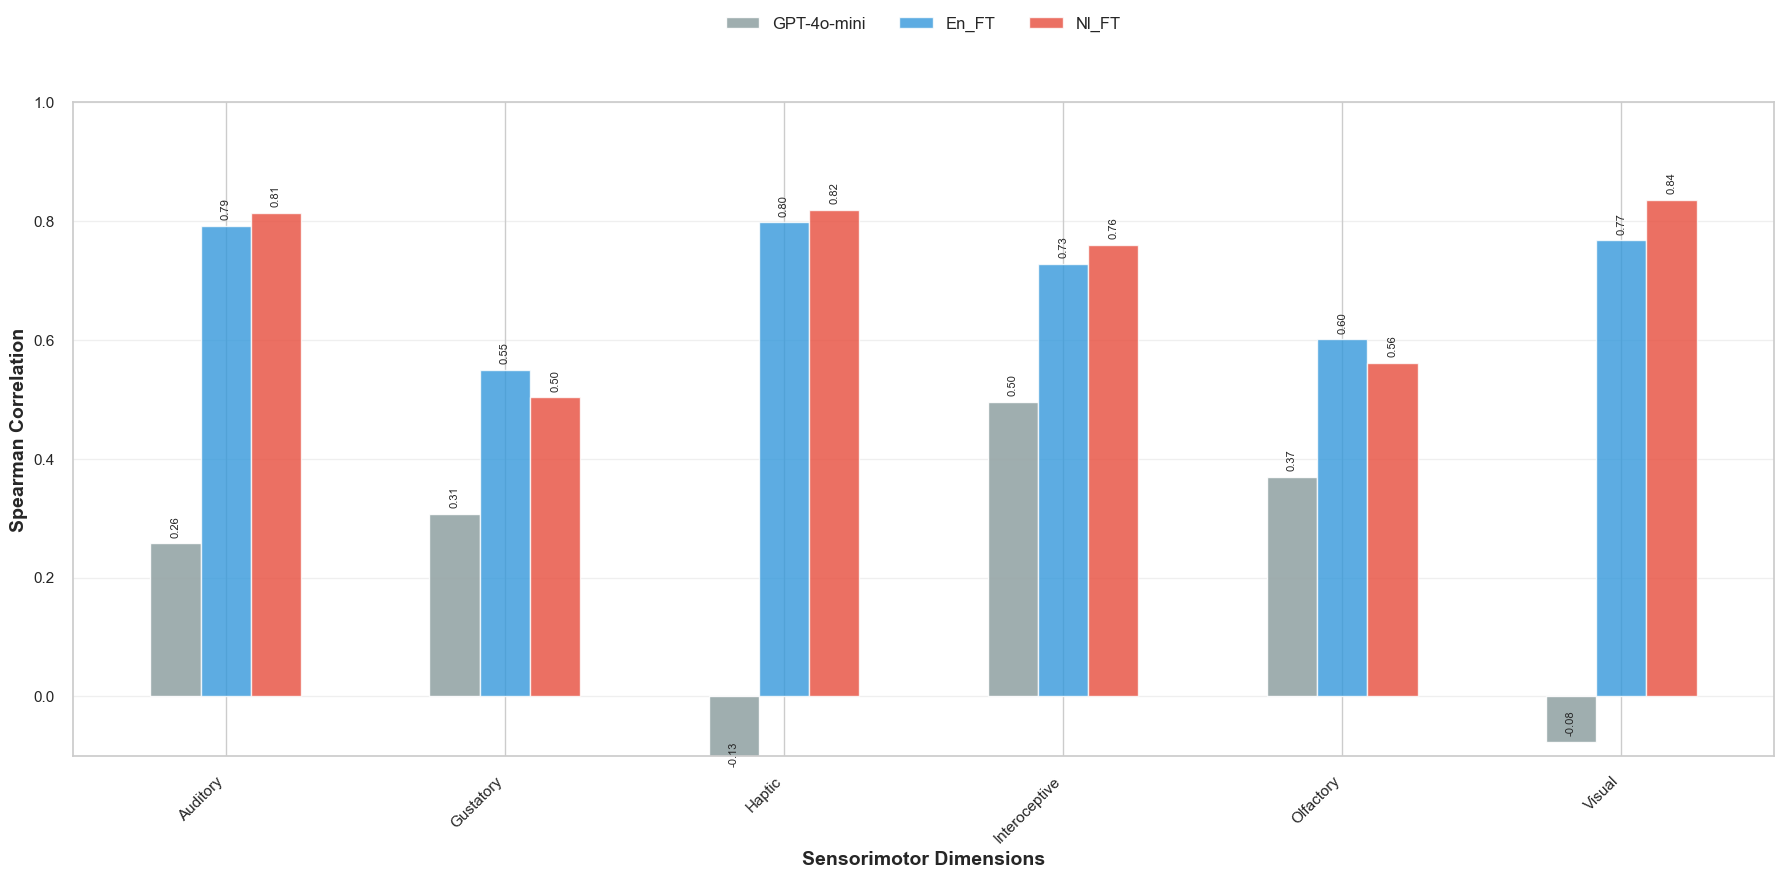

In [9]:
# Set chart size
fig, ax = plt.subplots(figsize=(18, 9))

# Data preparation
categories_spearman_nl = results_nl['Dimension']

# Data (Bars)
base_spearman_nl = results_nl['base_Spearman'].tolist()
en_ft_spearman_nl = results_nl['en_ft_Spearman'].tolist()
nl_ft_spearman_nl = results_nl['nl_ft_Spearman'].tolist()

# Significance data (P-values)
p_base_vs_en_nl = results_nl['p_base_vs_en'].tolist()
p_base_vs_nl_nl = results_nl['p_base_vs_nl'].tolist()
p_en_vs_nl_nl = results_nl['p_en_vs_nl'].tolist()

# Set bar width
bar_width_nl = 0.18

# Set X-axis position
index_nl = np.arange(len(categories_spearman_nl))

# Plot bars: Order Base -> En -> Nl
# 1. Base (Position 1: Left)
rects1 = ax.bar(index_nl - bar_width_nl, base_spearman_nl, bar_width_nl, label='GPT-4o-mini', color='#95a5a6' , alpha=0.9, edgecolor='white')

# 2. En_FT (Position 2: Middle) - Cross-lingual
rects2 = ax.bar(index_nl, en_ft_spearman_nl, bar_width_nl, label='En_FT', color='#3498db', alpha=0.8, edgecolor='white')

# 3. Nl_FT (Position 3: Right) - Target Language
rects3 = ax.bar(index_nl + bar_width_nl, nl_ft_spearman_nl, bar_width_nl, label='Nl_FT', color='#e74c3c' , alpha=0.8, edgecolor='white')

# Add labels and title
ax.set_xlabel('Sensorimotor Dimensions', fontsize=14, fontweight='bold')
ax.set_ylabel('Spearman Correlation', fontsize=14, fontweight='bold')
ax.set_title('', fontsize=16, fontweight='bold', pad=30)
ax.set_xticks(index_nl)
#ax.set_xticklabels(categories_spearman_nl, rotation=45, ha='right', fontsize=11)

# [!] 修改部分：添加中英对照标签
# 定义映射字典
nl_to_en_map = {
    'Horen': 'Auditory',
    'Proeven': 'Gustatory',
    'Voelen': 'Haptic',
    'Sensaties': 'Interoceptive',
    'Ruiken': 'Olfactory',
    'Zien': 'Visual'
}

# 生成仅英文标签列表
english_labels = [nl_to_en_map.get(dim, dim) for dim in categories_spearman_nl]

# 应用新标签
ax.set_xticklabels(english_labels, rotation=45, ha='right', fontsize=11)

# Legend
ax.legend(loc='center', bbox_to_anchor=(0.5, 1.12), ncol=3, fontsize=12, frameon=False)

# Grid and limits
ax.grid(True, axis='y', alpha=0.3)
ax.set_axisbelow(True)
ax.set_ylim(-0.1, 1)

# Value labels
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2., height + 0.01,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=8, rotation=90)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

# ===== Draw Significance Markers (Red for NS) =====

SIGNIFICANCE_COLOR = '#505050'
VERTICAL_SPACING = 0.065
MARKER_OFFSET = 0.06
NS_COLOR = '#d62728' 

for i in range(len(index_nl)):
    # 1. Get heights
    h_base = base_spearman_nl[i]
    h_en = en_ft_spearman_nl[i]
    h_nl = nl_ft_spearman_nl[i]
    
    # 2. X positions
    x1 = index_nl[i] - bar_width_nl # Base
    x2 = index_nl[i]                # En
    x3 = index_nl[i] + bar_width_nl # Nl

    current_y = max(h_base, h_en, h_nl) + MARKER_OFFSET
    
    # Comparisons (Ordered by visual span)
    comparisons = [
        (p_base_vs_en_nl[i], x1, x2), # Base vs En
        (p_en_vs_nl_nl[i],   x2, x3), # En vs Nl
        (p_base_vs_nl_nl[i], x1, x3), # Base vs Nl (Widest)
    ]
    
    for p_val, sx, ex in comparisons:
        # Only mark if Non-Significant (p >= 0.05)
        if not pd.isna(p_val) and p_val >= 0.05:
            ax.plot([sx, sx, ex, ex], 
                    [current_y-0.01, current_y, current_y, current_y-0.01], 
                    color=NS_COLOR, linewidth=1.2)
            ax.text((sx+ex)/2, current_y + 0.01, "ns", 
                    ha='center', va='bottom', color=NS_COLOR, fontsize=10, fontweight='bold')
            current_y += VERTICAL_SPACING

plt.tight_layout()
plt.show()